In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import scanpy as sc
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib as mpl
from matplotlib.pyplot import rc_context
import os
import seaborn as sns
import importlib
import re

In [2]:
import degSummary
from scanpyColor import godsnot_102

In [3]:
from adjustText import adjust_text

In [4]:
from scipy.stats import ranksums

In [36]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=150, facecolor='white', dpi_save=600)

scanpy==1.9.3 anndata==0.10.8 umap==0.5.3 numpy==1.23.5 scipy==1.11.4 pandas==2.2.1 scikit-learn==1.5.1 statsmodels==0.14.2 python-igraph==0.11.6 louvain==0.8.0 pynndescent==0.5.12


In [37]:
sns.set_theme(style="ticks")

# Load data

In [7]:
os.chdir('../..')

In [8]:
pwd

'/data/tcl/Project/HongjieLab/rapamycin'

In [9]:
figureFolder = 'Analysis/Figure'
os.makedirs(figureFolder, exist_ok=True)

In [10]:
flyphoneFolder=f'{figureFolder}/Figure_Flyphone'
os.makedirs(flyphoneFolder, exist_ok=True)
flyphonePicFolder=f'{flyphoneFolder}/pic'
os.makedirs(flyphonePicFolder, exist_ok=True)

# Summry of CCC

## Load data

In [11]:
adata_body = sc.read(f'/data/tcl/Project/HongjieLab/rapamycin/adataProcess/v1.0/adata_rapafca_body_v1.0.h5ad')
adata_head = sc.read(f'/data/tcl/Project/HongjieLab/rapamycin/adataProcess/v1.0/adata_rapafca_head_v1.0.h5ad')

/data/tcl/miniconda3/envs/scvi/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/data/tcl/miniconda3/envs/scvi/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [12]:
adata_headBody = adata_head.concatenate(adata_body, join='outer')
adata_headBody

<ipython-input-12-d569f6e12017>:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_headBody = adata_head.concatenate(adata_body, join='outer')


AnnData object with n_obs × n_vars = 505731 × 15919
    obs: 'latent_RT_efficiency', 'latent_cell_probability', 'latent_scale', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'dataset', 'age', 'sex', 'tissue', 'condition', 'leiden', 'linearR_annotation', 'condAge', 'condSex', 'ageSex', 'condAgeSex', 'condAgeSexTissue', 'leiden_1.0', 'leiden_2.0', 'leiden_3.0', 'leiden_4.0', 'leiden_5.0', 'leiden_6.0', 'leiden_7.0', 'leiden_8.0', 'leiden_9.0', 'leiden_10.0', 'leiden_1.5', 'treatment', 'treatAge', 'treatAgeSex', 'treatSex', 'rapamycin_annotation', 'rapamycin_annotation_broad', 'rapamycin_annotation_subcluster', 'rapamycin_annotation_group', 'batch'
    var: 'gene_ids', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1'
    obsm: 'X_pca', 'X_pca_original', 'X_tsne', 'X_umap', 'latent_gene_encoding'
    layers: 'counts', 'logNor'

In [13]:
annotation_Df=pd.read_csv('/data/tcl/genomes/fly/geneName_flybaseID_602_616_631_ensemblBDGP6.88.csv')
annotation_Df

,FlyBaseID,geneName_6.02,geneName_6.16,geneName_6.31,ensembl_BDGP6.88
0,FBgn0000003,7SLRNA:CR32864,7SLRNA:CR32864,7SLRNA:CR32864,7SLRNA:CR32864
1,FBgn0000008,a,a,a,a
2,FBgn0000014,abd-A,abd-A,abd-A,abd-A
3,FBgn0000015,Abd-B,Abd-B,Abd-B,Abd-B
4,FBgn0000017,Abl,Abl,Abl,Abl
...,...,...,...,...,...
18048,FBgn0287218,NaN,NaN,CG46448,NaN
18049,FBgn0287225,NaN,NaN,bor,NaN
18050,FBgn0287234,NaN,NaN,slf,NaN
18051,FBgn0287423,NaN,NaN,Nplp2,NaN


## LR interaction

In [14]:
sex='female'

<ipython-input-15-40bd2aef2d8f>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nmj_Df.sort_values(by='score_difference', ascending=False, inplace=True)


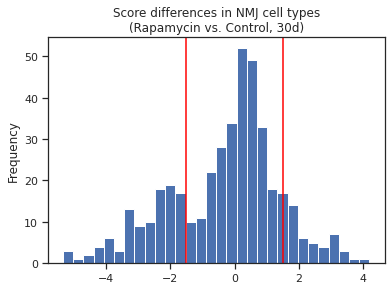

indirect_flight_muscle
muscle_cell
adult_ventral_nervous_system


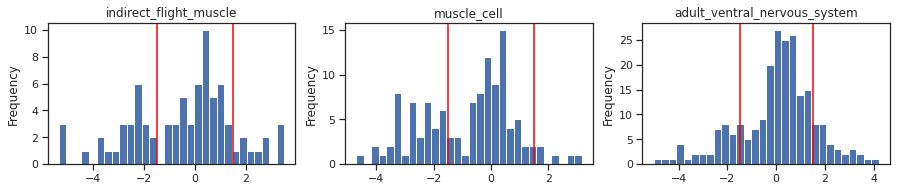

<ipython-input-15-40bd2aef2d8f>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nmj_Df.sort_values(by='score_difference', ascending=False, inplace=True)


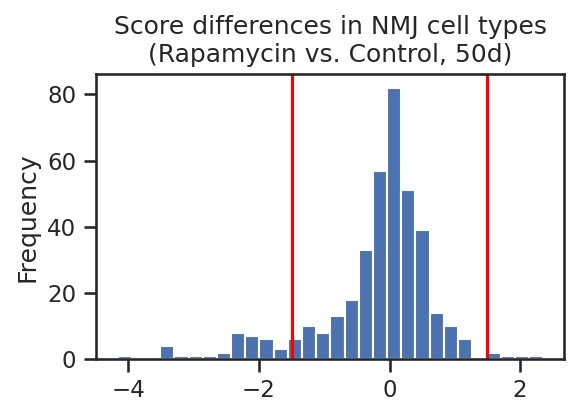

indirect_flight_muscle
muscle_cell
adult_ventral_nervous_system


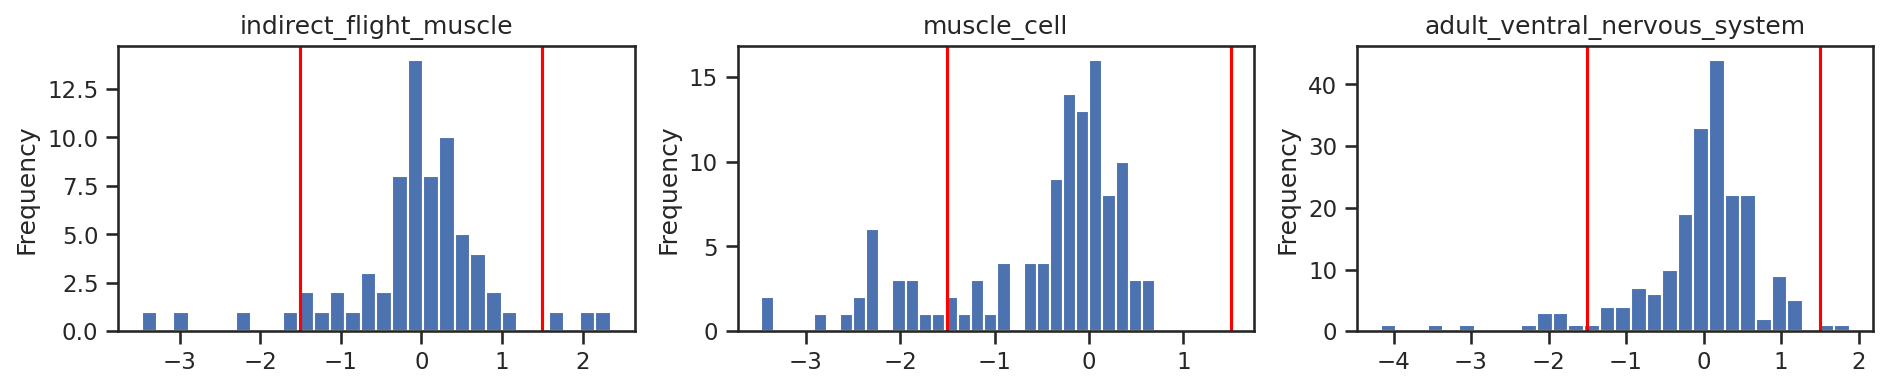

In [15]:
concatAllAges_Df=pd.DataFrame()
nmjAllAges_Df=pd.DataFrame()

for age in ['30', '50']:
    all_sheets_dict = pd.read_excel(f'{flyphoneFolder}/female/flyphone_results/Rapamycin_and_Control_interaction_list_{sex}_{age}.xlsx', sheet_name=None)
    
    ### dataframe from different sheets
    concat_Df = pd.DataFrame()
    for sheet in all_sheets_dict.keys():
        if len(concat_Df) == 0: concat_Df=all_sheets_dict[sheet]
        else: concat_Df = pd.concat([concat_Df, all_sheets_dict[sheet]])
        
    concat_Df['score_difference_abs'] = abs(concat_Df.score_difference)
    concat_Df['LR_pairName'] = pd.Categorical(concat_Df.Gene_secreted.astype(str) + '_' + concat_Df.Gene_receptor.astype(str))
    concat_Df.insert(0, 'age', age)
    
           
    ### Restricted to NMJ tissues
    nmj_Df = concat_Df[ (concat_Df.secretor.isin(['adult_ventral_nervous_system', 'muscle_cell', 'indirect_flight_muscle'])) & 
                        (concat_Df.receptor.isin(['adult_ventral_nervous_system', 'muscle_cell', 'indirect_flight_muscle'])) ]
    nmj_Df.sort_values(by='score_difference', ascending=False, inplace=True)
    # nmj_Df['score_difference_abs'] = abs(nmj_Df.score_difference)
    # nmj_Df['LR_pairName'] = pd.Categorical(nmj_Df.Gene_secreted.astype(str) + '_' + nmj_Df.Gene_receptor.astype(str))
    
    
    ### Summarize all ages
    if len(concatAllAges_Df) == 0: 
        concatAllAges_Df = concat_Df.copy()
        nmjAllAges_Df = nmj_Df.copy()
    else: 
        concatAllAges_Df = pd.concat([concatAllAges_Df, concat_Df])
        nmjAllAges_Df = pd.concat([nmjAllAges_Df, nmj_Df])
    
    
    ### Plot score differences (Rapamycin vs. Control)
    with rc_context({'figure.figsize': (4, 2.5)}):
        nmj_Df['score_difference'].plot.hist(bins=30)
        plt.axvline(-1.5, c='red')
        plt.axvline( 1.5, c='red')
        plt.title(f'Score differences in NMJ cell types\n(Rapamycin vs. Control, {age}d)')
        plt.savefig(f'{flyphonePicFolder}/histogram__nmj_Df__{sex}__{age}d.pdf', bbox_inches='tight')
        plt.show()
        plt.close()
        
        figs, axs = plt.subplots(1, 3, figsize=(15,2.5))
        for n, ct in enumerate(set(nmj_Df.secretor)):
            print(ct)
            nmj_Df[nmj_Df.secretor == ct]['score_difference'].plot.hist(ax=axs[n], bins=30)
            axs[n].set_title(f'{ct}')
            axs[n].axvline(x=-1.5, color='red')
            axs[n].axvline(x= 1.5, color='red')
        plt.savefig(f'{flyphonePicFolder}/histogram__nmj_Df__{sex}__{age}d__eachCellType.pdf', bbox_inches='tight')
        plt.show()
        plt.close()
    
    
    ### Export 
    ccc_Df = pd.DataFrame(nmj_Df[ nmj_Df.score_difference_abs > 1.5]['LR_pairName'].value_counts())
    ccc_Df.to_csv(f'{flyphoneFolder}/LR_count_1.5__{sex}__{age}d.csv',)
    

In [16]:
nmjAllAges_Df

,age,Gene_secreted,Gene_receptor,pathway_receptor,secretor,receptor,score_Control,pval_Control,score_Rapamycin,pval_Rapamycin,secreted_gene_deg_status,receptor_gene_deg_status,score_log2fc,score_difference,direction,specificity,score_difference_abs,LR_pairName
1758,30,mmd,Tsp96F,other,adult_ventral_nervous_system,muscle_cell,0.000000,1.0,4.203552,0.0,Rapamycin,Rapamycin,31.968962,4.203552,Rapamycin,significant_signaling_in_Rapamycin,4.203552,mmd_Tsp96F
2123,30,Cam,Ptp36E,other,adult_ventral_nervous_system,indirect_flight_muscle,0.000000,1.0,3.839308,0.0,Rapamycin,Rapamycin,31.838199,3.839308,Rapamycin,significant_signaling_in_Rapamycin,3.839308,Cam_Ptp36E
2160,30,Cam,KCNQ,other,adult_ventral_nervous_system,indirect_flight_muscle,0.000000,1.0,3.539548,0.0,Rapamycin,NaN,31.720918,3.539548,Rapamycin,significant_signaling_in_Rapamycin,3.539548,Cam_KCNQ
2143,30,Cam,Ptp36E,other,indirect_flight_muscle,indirect_flight_muscle,0.000000,1.0,3.522136,0.0,NaN,Rapamycin,31.713803,3.522136,Rapamycin,significant_signaling_in_Rapamycin,3.522136,Cam_Ptp36E
1726,30,Appl,Tsp96F,other,adult_ventral_nervous_system,muscle_cell,0.000000,1.0,3.461782,0.0,Rapamycin,Rapamycin,31.688868,3.461782,Rapamycin,significant_signaling_in_Rapamycin,3.461782,Appl_Tsp96F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3338,50,Antp,Glut1,other,muscle_cell,adult_ventral_nervous_system,3.439178,0.0,0.000000,1.0,NaN,Rapamycin,-31.679416,-3.439178,Control,significant_signaling_in_Control,3.439178,Antp_Glut1
2263,50,Cam,Pde1c,other,indirect_flight_muscle,indirect_flight_muscle,3.468105,0.0,0.000000,1.0,NaN,Control,-31.691501,-3.468105,Control,significant_signaling_in_Control,3.468105,Cam_Pde1c
419,50,Fas1,Fas1,other,muscle_cell,adult_ventral_nervous_system,3.473285,0.0,0.000000,1.0,Control,Rapamycin,-31.693654,-3.473285,Control,significant_signaling_in_Control,3.473285,Fas1_Fas1
414,50,Fas1,Fas1,other,adult_ventral_nervous_system,muscle_cell,3.473285,0.0,0.000000,1.0,Rapamycin,Control,-31.693654,-3.473285,Control,significant_signaling_in_Control,3.473285,Fas1_Fas1


In [17]:
concatAllAges_Df.to_csv(f'{flyphoneFolder}/female/flyphone_results/Rapamycin_and_Control_interaction_list_{sex}_30d50d.csv', index=None)
nmjAllAges_Df.to_csv(f'{flyphoneFolder}/female/flyphone_results/Rapamycin_and_Control_interaction_list_{sex}_30d50d_nmj.csv', index=None)
concatAllAges_Df

,age,Gene_secreted,Gene_receptor,pathway_receptor,secretor,receptor,score_Control,pval_Control,score_Rapamycin,pval_Rapamycin,secreted_gene_deg_status,receptor_gene_deg_status,score_log2fc,score_difference,direction,specificity,score_difference_abs,LR_pairName
0,30,kirre,sns,Nephrin signaling pathway,16_cell_germline_cyst_in_germarium_region_2a_a...,adult_ventral_nervous_system,6.145862,0.0,7.520139,0.000,Rapamycin,NaN,0.291144,1.374277,Rapamycin,significant_signaling_both_conditions,1.374277,kirre_sns
1,30,kirre,sns,Nephrin signaling pathway,adult_ventral_nervous_system,adult_ventral_nervous_system,2.495032,0.0,3.239294,0.000,Rapamycin,NaN,0.376621,0.744262,Rapamycin,significant_signaling_both_conditions,0.744262,kirre_sns
2,30,kirre,sns,Nephrin signaling pathway,enterocyte_of_anterior_adult_midgut_epithelium,adult_ventral_nervous_system,1.736758,0.0,2.281018,0.000,Rapamycin,NaN,0.393281,0.544260,Rapamycin,significant_signaling_both_conditions,0.544260,kirre_sns
3,30,kirre,sns,Nephrin signaling pathway,female_reproductive_system,adult_ventral_nervous_system,1.835985,0.0,1.853312,0.000,Control,NaN,0.013551,0.017327,Rapamycin,significant_signaling_both_conditions,0.017327,kirre_sns
4,30,kirre,sns,Nephrin signaling pathway,germline_cell,adult_ventral_nervous_system,4.200293,0.0,4.770240,0.000,Control,NaN,0.183572,0.569946,Rapamycin,significant_signaling_both_conditions,0.569946,kirre_sns
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16928,50,deltaTry,Ire1,other,enterocyte_like,hemocyte_body,0.000000,1.0,0.879242,0.000,NaN,NaN,29.711684,0.879242,Rapamycin,tissue_specific_unchanged_signaling,0.879242,deltaTry_Ire1
16929,50,alphaTry,dtn,other,enterocyte_like,adult_alary_muscle,0.000000,1.0,2.143390,0.005,NaN,NaN,30.997247,2.143390,Rapamycin,tissue_specific_unchanged_signaling,2.143390,alphaTry_dtn
16930,50,alphaTry,dtn,other,midgut_large_flat_cell,adult_alary_muscle,0.000000,1.0,1.260804,0.035,NaN,NaN,30.231696,1.260804,Rapamycin,tissue_specific_unchanged_signaling,1.260804,alphaTry_dtn
16931,50,deltaTry,dtn,other,enterocyte_like,adult_alary_muscle,0.000000,1.0,1.009513,0.000,NaN,NaN,29.911012,1.009513,Rapamycin,tissue_specific_unchanged_signaling,1.009513,deltaTry_dtn


In [18]:
nmjAllAges_Df_diff15 = nmjAllAges_Df[ nmjAllAges_Df.score_difference_abs > 1.5]
nmjAllAges_Df_diff15.reset_index(drop=True, inplace=True)

nmjAllAges_Df_diff15.to_csv(f'{flyphoneFolder}/female/flyphone_results/nmjAllAges_Df_diff15_{sex}_30d50d_nmj.csv', index=None)

nmjAllAges_Df_diff15

,age,Gene_secreted,Gene_receptor,pathway_receptor,secretor,receptor,score_Control,pval_Control,score_Rapamycin,pval_Rapamycin,secreted_gene_deg_status,receptor_gene_deg_status,score_log2fc,score_difference,direction,specificity,score_difference_abs,LR_pairName
0,30,mmd,Tsp96F,other,adult_ventral_nervous_system,muscle_cell,0.000000,1.0,4.203552,0.0,Rapamycin,Rapamycin,31.968962,4.203552,Rapamycin,significant_signaling_in_Rapamycin,4.203552,mmd_Tsp96F
1,30,Cam,Ptp36E,other,adult_ventral_nervous_system,indirect_flight_muscle,0.000000,1.0,3.839308,0.0,Rapamycin,Rapamycin,31.838199,3.839308,Rapamycin,significant_signaling_in_Rapamycin,3.839308,Cam_Ptp36E
2,30,Cam,KCNQ,other,adult_ventral_nervous_system,indirect_flight_muscle,0.000000,1.0,3.539548,0.0,Rapamycin,NaN,31.720918,3.539548,Rapamycin,significant_signaling_in_Rapamycin,3.539548,Cam_KCNQ
3,30,Cam,Ptp36E,other,indirect_flight_muscle,indirect_flight_muscle,0.000000,1.0,3.522136,0.0,NaN,Rapamycin,31.713803,3.522136,Rapamycin,significant_signaling_in_Rapamycin,3.522136,Cam_Ptp36E
4,30,Appl,Tsp96F,other,adult_ventral_nervous_system,muscle_cell,0.000000,1.0,3.461782,0.0,Rapamycin,Rapamycin,31.688868,3.461782,Rapamycin,significant_signaling_in_Rapamycin,3.461782,Appl_Tsp96F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,50,Antp,Glut1,other,muscle_cell,adult_ventral_nervous_system,3.439178,0.0,0.000000,1.0,NaN,Rapamycin,-31.679416,-3.439178,Control,significant_signaling_in_Control,3.439178,Antp_Glut1
188,50,Cam,Pde1c,other,indirect_flight_muscle,indirect_flight_muscle,3.468105,0.0,0.000000,1.0,NaN,Control,-31.691501,-3.468105,Control,significant_signaling_in_Control,3.468105,Cam_Pde1c
189,50,Fas1,Fas1,other,muscle_cell,adult_ventral_nervous_system,3.473285,0.0,0.000000,1.0,Control,Rapamycin,-31.693654,-3.473285,Control,significant_signaling_in_Control,3.473285,Fas1_Fas1
190,50,Fas1,Fas1,other,adult_ventral_nervous_system,muscle_cell,3.473285,0.0,0.000000,1.0,Rapamycin,Control,-31.693654,-3.473285,Control,significant_signaling_in_Control,3.473285,Fas1_Fas1


In [19]:
### all group

nmjDiffCCC_Df = pd.DataFrame(index=list(set(nmjAllAges_Df_diff15.secretor)), 
                             columns=list(set(nmjAllAges_Df_diff15.receptor))  )

for n, secretor in enumerate(nmjDiffCCC_Df.index):
    for k, receptor in enumerate(nmjDiffCCC_Df.columns):
        # print(secretor, receptor)
        
        count = len(nmjAllAges_Df_diff15[ (nmjAllAges_Df_diff15.secretor == secretor) & (nmjAllAges_Df_diff15.receptor == receptor) ])
        # print(count)
        
        nmjDiffCCC_Df.iloc[n,k] = count

nmjDiffCCC_Df.index = [idx+'_' for idx in nmjDiffCCC_Df.index]
nmjDiffCCC_Df

,indirect_flight_muscle,muscle_cell,adult_ventral_nervous_system
indirect_flight_muscle_,8,13,21
muscle_cell_,17,28,25
adult_ventral_nervous_system_,16,34,30


In [20]:
### 30d group

nmjAllAges_Df_diff15_30 = nmjAllAges_Df_diff15[nmjAllAges_Df_diff15.age == '30']

nmjDiffCCC_Df_30 = pd.DataFrame(index=list(set(nmjAllAges_Df_diff15.secretor)), 
                             columns=list(set(nmjAllAges_Df_diff15.receptor))  )

for n, secretor in enumerate(nmjDiffCCC_Df_30.index):
    for k, receptor in enumerate(nmjDiffCCC_Df_30.columns):
        # print(secretor, receptor)
        
        count = len(nmjAllAges_Df_diff15_30[ (nmjAllAges_Df_diff15_30.secretor == secretor) & (nmjAllAges_Df_diff15_30.receptor == receptor) ])
        # print(count)
        
        nmjDiffCCC_Df_30.iloc[n,k] = count

nmjDiffCCC_Df_30.index = [idx+'_' for idx in nmjDiffCCC_Df_30.index]
nmjDiffCCC_Df_30

,indirect_flight_muscle,muscle_cell,adult_ventral_nervous_system
indirect_flight_muscle_,6,10,19
muscle_cell_,11,20,17
adult_ventral_nervous_system_,14,24,29


In [21]:
### 50d group

nmjAllAges_Df_diff15_50 = nmjAllAges_Df_diff15[nmjAllAges_Df_diff15.age == '50']

nmjDiffCCC_Df_50 = pd.DataFrame(index=list(set(nmjAllAges_Df_diff15.secretor)), 
                             columns=list(set(nmjAllAges_Df_diff15.receptor))  )

for n, secretor in enumerate(nmjDiffCCC_Df_50.index):
    for k, receptor in enumerate(nmjDiffCCC_Df_50.columns):
        # print(secretor, receptor)
        
        count = len(nmjAllAges_Df_diff15_50[ (nmjAllAges_Df_diff15_50.secretor == secretor) & (nmjAllAges_Df_diff15_50.receptor == receptor) ])
        # print(count)
        
        nmjDiffCCC_Df_50.iloc[n,k] = count

nmjDiffCCC_Df_50.index = [idx+'_' for idx in nmjDiffCCC_Df_50.index]
nmjDiffCCC_Df_50

,indirect_flight_muscle,muscle_cell,adult_ventral_nervous_system
indirect_flight_muscle_,2,3,2
muscle_cell_,6,8,8
adult_ventral_nervous_system_,2,10,1


In [64]:
nmjAllAges_Df_diff15['secretor_age'].value_counts()

secretor_age
adult_ventral_nervous_system_30    67
muscle_cell_30                     48
indirect_flight_muscle_30          35
muscle_cell_50                     22
adult_ventral_nervous_system_50    13
indirect_flight_muscle_50           7
Name: count, dtype: int64

In [22]:
nmjAllAges_Df_diff15['secretor_age'] = pd.Categorical(nmjAllAges_Df_diff15['secretor'].astype(str) + '__' + nmjAllAges_Df_diff15['age'].astype(str), 
                                                      categories=['adult_ventral_nervous_system__30', 'muscle_cell__30', 'indirect_flight_muscle__30', 
                                                      'adult_ventral_nervous_system__50', 'muscle_cell__50', 'indirect_flight_muscle__50'])
nmjAllAges_Df_diff15['receptor_age'] = pd.Categorical(nmjAllAges_Df_diff15['receptor'].astype(str) + '__' + nmjAllAges_Df_diff15['age'].astype(str),
                                                      categories=['adult_ventral_nervous_system__30', 'muscle_cell__30', 'indirect_flight_muscle__30', 
                                                      'adult_ventral_nervous_system__50', 'muscle_cell__50', 'indirect_flight_muscle__50'])
nmjAllAges_Df_diff15

<ipython-input-22-019e1957f9c0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nmjAllAges_Df_diff15['secretor_age'] = pd.Categorical(nmjAllAges_Df_diff15['secretor'].astype(str) + '__' + nmjAllAges_Df_diff15['age'].astype(str),
<ipython-input-22-019e1957f9c0>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nmjAllAges_Df_diff15['receptor_age'] = pd.Categorical(nmjAllAges_Df_diff15['receptor'].astype(str) + '__' + nmjAllAges_Df_diff15['age'].astype(str),


,age,Gene_secreted,Gene_receptor,pathway_receptor,secretor,receptor,score_Control,pval_Control,score_Rapamycin,pval_Rapamycin,secreted_gene_deg_status,receptor_gene_deg_status,score_log2fc,score_difference,direction,specificity,score_difference_abs,LR_pairName,secretor_age,receptor_age
0,30,mmd,Tsp96F,other,adult_ventral_nervous_system,muscle_cell,0.000000,1.0,4.203552,0.0,Rapamycin,Rapamycin,31.968962,4.203552,Rapamycin,significant_signaling_in_Rapamycin,4.203552,mmd_Tsp96F,adult_ventral_nervous_system__30,muscle_cell__30
1,30,Cam,Ptp36E,other,adult_ventral_nervous_system,indirect_flight_muscle,0.000000,1.0,3.839308,0.0,Rapamycin,Rapamycin,31.838199,3.839308,Rapamycin,significant_signaling_in_Rapamycin,3.839308,Cam_Ptp36E,adult_ventral_nervous_system__30,indirect_flight_muscle__30
2,30,Cam,KCNQ,other,adult_ventral_nervous_system,indirect_flight_muscle,0.000000,1.0,3.539548,0.0,Rapamycin,NaN,31.720918,3.539548,Rapamycin,significant_signaling_in_Rapamycin,3.539548,Cam_KCNQ,adult_ventral_nervous_system__30,indirect_flight_muscle__30
3,30,Cam,Ptp36E,other,indirect_flight_muscle,indirect_flight_muscle,0.000000,1.0,3.522136,0.0,NaN,Rapamycin,31.713803,3.522136,Rapamycin,significant_signaling_in_Rapamycin,3.522136,Cam_Ptp36E,indirect_flight_muscle__30,indirect_flight_muscle__30
4,30,Appl,Tsp96F,other,adult_ventral_nervous_system,muscle_cell,0.000000,1.0,3.461782,0.0,Rapamycin,Rapamycin,31.688868,3.461782,Rapamycin,significant_signaling_in_Rapamycin,3.461782,Appl_Tsp96F,adult_ventral_nervous_system__30,muscle_cell__30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,50,Antp,Glut1,other,muscle_cell,adult_ventral_nervous_system,3.439178,0.0,0.000000,1.0,NaN,Rapamycin,-31.679416,-3.439178,Control,significant_signaling_in_Control,3.439178,Antp_Glut1,muscle_cell__50,adult_ventral_nervous_system__50
188,50,Cam,Pde1c,other,indirect_flight_muscle,indirect_flight_muscle,3.468105,0.0,0.000000,1.0,NaN,Control,-31.691501,-3.468105,Control,significant_signaling_in_Control,3.468105,Cam_Pde1c,indirect_flight_muscle__50,indirect_flight_muscle__50
189,50,Fas1,Fas1,other,muscle_cell,adult_ventral_nervous_system,3.473285,0.0,0.000000,1.0,Control,Rapamycin,-31.693654,-3.473285,Control,significant_signaling_in_Control,3.473285,Fas1_Fas1,muscle_cell__50,adult_ventral_nervous_system__50
190,50,Fas1,Fas1,other,adult_ventral_nervous_system,muscle_cell,3.473285,0.0,0.000000,1.0,Rapamycin,Control,-31.693654,-3.473285,Control,significant_signaling_in_Control,3.473285,Fas1_Fas1,adult_ventral_nervous_system__50,muscle_cell__50


In [23]:
from pySankey.sankey import sankey

In [24]:
palette = sns.color_palette('tab20').as_hex()

In [25]:
color_Df = pd.DataFrame() # columns=['secretor_age', 'colorCode']
color_Df['secretor_age'] = [f'{ct}__{age}' for age in ['30', '50'] for ct in list(set(nmjAllAges_Df_diff15.secretor))]
color_Df['colorCode'] = [color for color in palette[:6:2] + palette[1:6:2]]
color_D = dict(zip(color_Df['secretor_age'], color_Df['colorCode']))
color_Df

,secretor_age,colorCode
0,indirect_flight_muscle__30,#1f77b4
1,muscle_cell__30,#ff7f0e
2,adult_ventral_nervous_system__30,#2ca02c
3,indirect_flight_muscle__50,#aec7e8
4,muscle_cell__50,#ffbb78
5,adult_ventral_nervous_system__50,#98df8a


In [26]:
color_D

{'indirect_flight_muscle__30': '#1f77b4',
 'muscle_cell__30': '#ff7f0e',
 'adult_ventral_nervous_system__30': '#2ca02c',
 'indirect_flight_muscle__50': '#aec7e8',
 'muscle_cell__50': '#ffbb78',
 'adult_ventral_nervous_system__50': '#98df8a'}

In [93]:
colors = {
    'adult_ventral_nervous_system__30': '#1f77b4',
    'muscle_cell__30': '#ff7f0e',
    'indirect_flight_muscle__30': '#2ca02c',
    'adult_ventral_nervous_system__50': '#aec7e8',
    'muscle_cell__50': '#ffbb78',
    'indirect_flight_muscle__50': '#98df8a'   
}

In [ ]:
colors = {
    "adult_ventral_nervous_system_30": "#f71b1b",
    "muscle_cell_30": "#1b7ef7",
    "indirect_flight_muscle_30": "#f3f71b",
    "adult_ventral_nervous_system_50": "#12e23f",
    "muscle_cell_50": "#f78c1b"
    
}

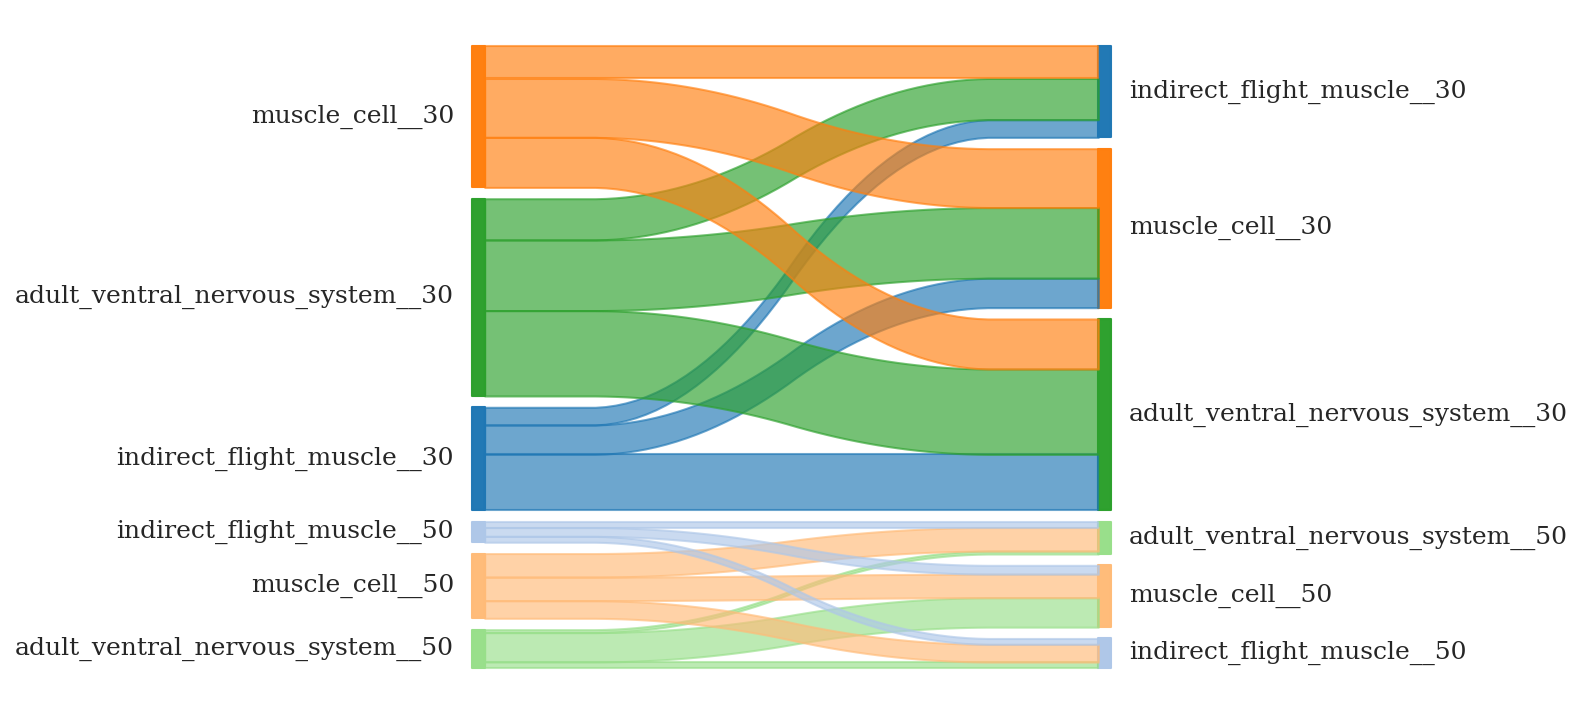

In [29]:
with rc_context({'figure.figsize': (3,6)}):
    sankey(nmjAllAges_Df_diff15.iloc[::-1,:]["secretor_age"], nmjAllAges_Df_diff15.iloc[::-1,:]["receptor_age"], aspect=20, fontsize=12, colorDict=color_D,
           # leftLabels=['adult_ventral_nervous_system_50', 'muscle_cell_50', 'indirect_flight_muscle_50', 'adult_ventral_nervous_system_30', 'muscle_cell_30', 'indirect_flight_muscle_30', ],
) #            rightLabels=['adult_ventral_nervous_system_30', 'muscle_cell_30', 'indirect_flight_muscle_30', 'adult_ventral_nervous_system_50', 'muscle_cell_50', 'indirect_flight_muscle_50']
plt.savefig(f'{flyphonePicFolder}/sankey__nmj__30d50d.pdf', bbox_inches='tight')

In [30]:
### output matrix
nmjDiffCCC_Df.to_csv(f'{flyphoneFolder}/female/flyphone_results/nmjDiffCCC_Df_{sex}.csv', ) # index=None
nmjDiffCCC_Df_30.to_csv(f'{flyphoneFolder}/female/flyphone_results/nmjDiffCCC_Df_30_{sex}.csv', )
nmjDiffCCC_Df_50.to_csv(f'{flyphoneFolder}/female/flyphone_results/nmjDiffCCC_Df_50_{sex}.csv',)

nmjAllAges_Df_diff15.to_csv(f'{flyphoneFolder}/female/flyphone_results/nmjAllAges_Df_diff15_{sex}.csv',)

In [31]:
df_30 = pd.read_csv(f'{flyphoneFolder}/LR_count_1.5__{sex}__30d.csv', index_col=0)
df_30.columns = ['count_30']
df_30.index.name = None
df_30['LR_pairName'] = df_30.index.to_list()

df_50 = pd.read_csv(f'{flyphoneFolder}/LR_count_1.5__{sex}__50d.csv', index_col=0)
df_50.columns = ['count_50']
df_50.index.name = None
df_50['LR_pairName'] = df_50.index.to_list()

In [32]:
df_30

,count_30,LR_pairName
N_Alk,8,N_Alk
Cam_Ptp36E,6,Cam_Ptp36E
dally_Tsp96F,6,dally_Tsp96F
Fas1_Fas1,4,Fas1_Fas1
Nrx-1_Nlg1,4,Nrx-1_Nlg1
...,...,...
Galphai_Octalpha2R,0,Galphai_Octalpha2R
Galphai_Oct-TyrR,0,Galphai_Oct-TyrR
Galphai_Lgr1,0,Galphai_Lgr1
Galphai_Dop2R,0,Galphai_Dop2R


In [33]:
ccc_Df = pd.merge(df_30, df_50, on='LR_pairName', how='left')
ccc_Df.fillna(0, inplace=True)
ccc_Df['sum'] = ccc_Df.count_30 + ccc_Df.count_50
ccc_Df.sort_values(by='sum', inplace=True, ascending=False)
ccc_Df.index = ccc_Df.LR_pairName.to_list()
order_L = ccc_Df.index.to_list()[:10]
order_L

['N_Alk',
 'Nrx-1_Nlg1',
 'Cam_Ptp36E',
 'Nlg1_Nrx-1',
 'Meltrin_Eph',
 'Fas1_Fas1',
 'dally_Tsp96F',
 'Meltrin_Tsp96F',
 'Hsp83_htl',
 'bnl_if']

In [34]:
df_30 = pd.read_csv(f'{flyphoneFolder}/LR_count_1.5__{sex}__30d.csv', index_col=0)
df_30['age'] = '30'

df_50 = pd.read_csv(f'{flyphoneFolder}/LR_count_1.5__{sex}__50d.csv', index_col=0)
df_50['age'] = '50'

concat_Df = pd.concat([df_30, df_50], axis=0)
concat_Df.index.name = None
concat_Df = concat_Df[concat_Df.index.isin(order_L)]
concat_Df['LR_pairName'] = pd.Categorical(concat_Df.index.to_list(), categories=concat_Df[concat_Df.age == '30'].sort_values(by='count', ascending=False).index.to_list())


concat_Df

,count,age,LR_pairName
N_Alk,8,30,N_Alk
Cam_Ptp36E,6,30,Cam_Ptp36E
dally_Tsp96F,6,30,dally_Tsp96F
Fas1_Fas1,4,30,Fas1_Fas1
Nrx-1_Nlg1,4,30,Nrx-1_Nlg1
Nlg1_Nrx-1,4,30,Nlg1_Nrx-1
Meltrin_Eph,3,30,Meltrin_Eph
bnl_if,2,30,bnl_if
Hsp83_htl,2,30,Hsp83_htl
Meltrin_Tsp96F,2,30,Meltrin_Tsp96F


/data/tcl/miniconda3/envs/scvi/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/data/tcl/miniconda3/envs/scvi/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


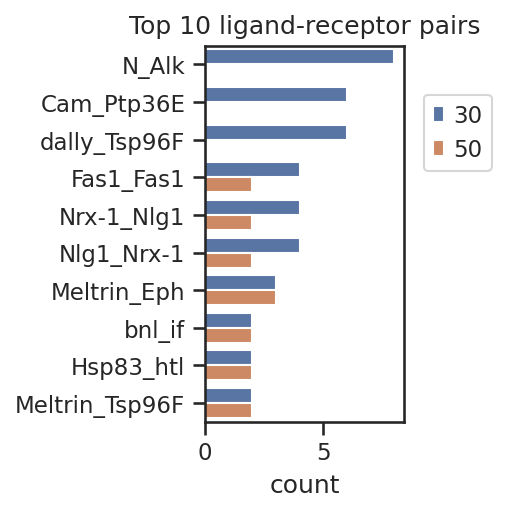

In [35]:
with rc_context({'figure.figsize':(1.7, 3.3)}):
    sns.barplot(data=concat_Df, x='count', y='LR_pairName', hue='age')
    plt.legend(bbox_to_anchor=(1.5, .9))
    plt.ylabel('')
    plt.title('Top 10 ligand-receptor pairs')
    plt.savefig(f'{flyphonePicFolder}/LR_count.pdf', bbox_inches='tight',)

# Finished